<a href="https://colab.research.google.com/github/hemanthsaigude/CN7030/blob/main/airlines.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install pyspark

In [2]:
from pyspark.sql import SparkSession
from pyspark.sql.functions import col, sum, avg, month, year, coalesce
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
spark = SparkSession.builder.appName("AirlineDelayAnalysis").getOrCreate()
file_path = "/content/Airline_Delay_Cause.csv"
df = spark.read.csv(file_path, header=True, inferSchema=True)

In [3]:
print("DataFrame Schema:")
df.printSchema()

print("\nFirst 5 rows of the DataFrame:")
df.show(5)

DataFrame Schema:
root
 |-- year: integer (nullable = true)
 |-- month: integer (nullable = true)
 |-- carrier: string (nullable = true)
 |-- carrier_name: string (nullable = true)
 |-- airport: string (nullable = true)
 |-- airport_name: string (nullable = true)
 |-- arr_flights: integer (nullable = true)
 |-- arr_del15: integer (nullable = true)
 |-- carrier_ct: double (nullable = true)
 |-- weather_ct: double (nullable = true)
 |-- nas_ct: double (nullable = true)
 |-- security_ct: double (nullable = true)
 |-- late_aircraft_ct: double (nullable = true)
 |-- arr_cancelled: integer (nullable = true)
 |-- arr_diverted: integer (nullable = true)
 |-- arr_delay: integer (nullable = true)
 |-- carrier_delay: integer (nullable = true)
 |-- weather_delay: integer (nullable = true)
 |-- nas_delay: integer (nullable = true)
 |-- security_delay: integer (nullable = true)
 |-- late_aircraft_delay: integer (nullable = true)


First 5 rows of the DataFrame:
+----+-----+-------+-------------+----

In [4]:
from pyspark.sql.functions import col, sum
print("Null value counts per column:")
df.select([sum(col(c).isNull().cast("integer")).alias(c) for c in df.columns]).show()

Null value counts per column:
+----+-----+-------+------------+-------+------------+-----------+---------+----------+----------+------+-----------+----------------+-------------+------------+---------+-------------+-------------+---------+--------------+-------------------+
|year|month|carrier|carrier_name|airport|airport_name|arr_flights|arr_del15|carrier_ct|weather_ct|nas_ct|security_ct|late_aircraft_ct|arr_cancelled|arr_diverted|arr_delay|carrier_delay|weather_delay|nas_delay|security_delay|late_aircraft_delay|
+----+-----+-------+------------+-------+------------+-----------+---------+----------+----------+------+-----------+----------------+-------------+------------+---------+-------------+-------------+---------+--------------+-------------------+
|   0|    0|      0|           0|      0|           0|        657|      950|       657|       657|   657|        657|             657|          657|         657|      657|          657|          657|      657|           657|           

In [5]:
columns_to_impute = [
    'arr_flights', 'arr_del15', 'carrier_ct', 'weather_ct', 'nas_ct',
    'security_ct', 'late_aircraft_ct', 'arr_cancelled', 'arr_diverted',
    'arr_delay', 'carrier_delay', 'weather_delay', 'nas_delay',
    'security_delay', 'late_aircraft_delay'
]
df = df.fillna(0, subset=columns_to_impute)

print("Null value counts per column after imputation:")
df.select([sum(col(c).isNull().cast("integer")).alias(c) for c in df.columns]).show()
print("\nDataFrame Schema after imputation:")
df.printSchema()

print("\nFirst 5 rows of the DataFrame after imputation:")
df.show(5)

Null value counts per column after imputation:
+----+-----+-------+------------+-------+------------+-----------+---------+----------+----------+------+-----------+----------------+-------------+------------+---------+-------------+-------------+---------+--------------+-------------------+
|year|month|carrier|carrier_name|airport|airport_name|arr_flights|arr_del15|carrier_ct|weather_ct|nas_ct|security_ct|late_aircraft_ct|arr_cancelled|arr_diverted|arr_delay|carrier_delay|weather_delay|nas_delay|security_delay|late_aircraft_delay|
+----+-----+-------+------------+-------+------------+-----------+---------+----------+----------+------+-----------+----------------+-------------+------------+---------+-------------+-------------+---------+--------------+-------------------+
|   0|    0|      0|           0|      0|           0|          0|        0|         0|         0|     0|          0|               0|            0|           0|        0|            0|            0|        0|         

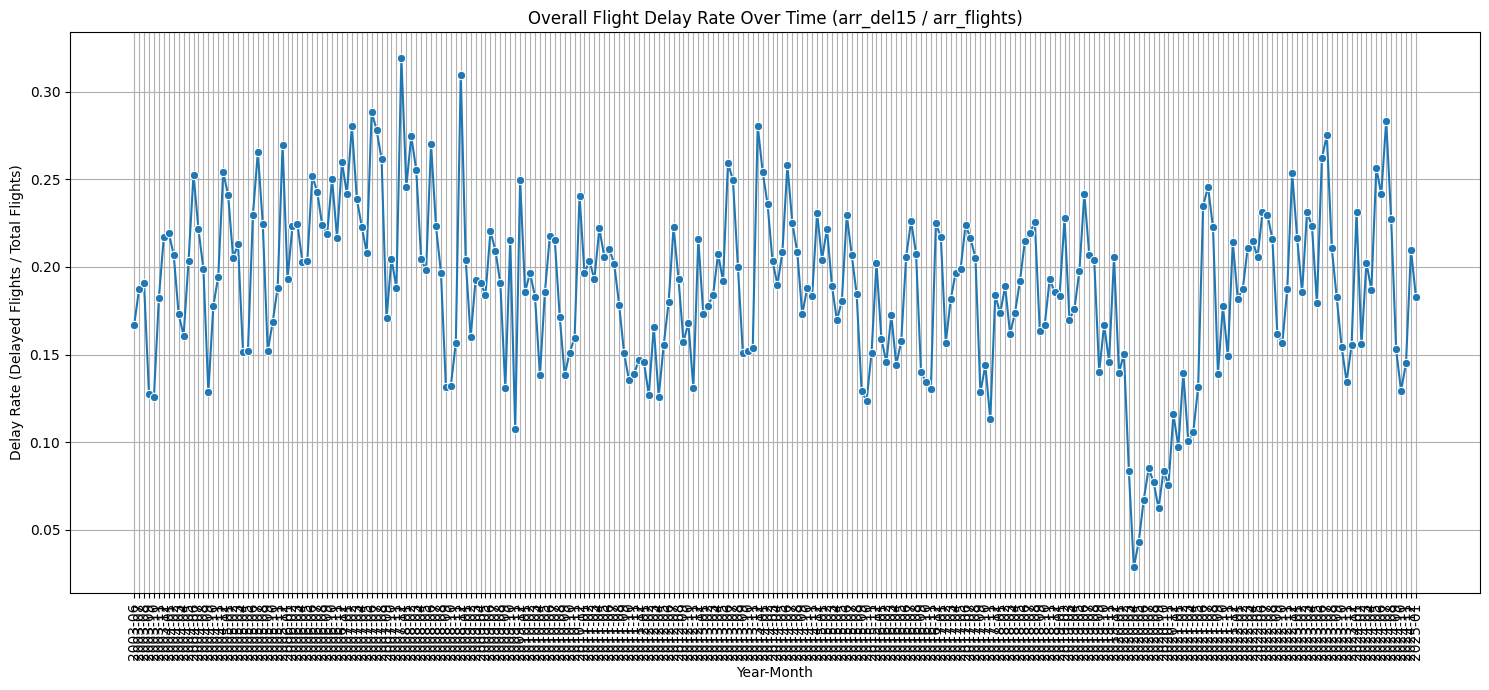

In [6]:
delay_over_time = df.groupBy("year", "month") \
                    .agg(sum("arr_del15").alias("total_delayed_flights"), \
                         sum("arr_flights").alias("total_flights")) \
                    .orderBy("year", "month")

delay_over_time = delay_over_time.withColumn("delay_rate",
                                           col("total_delayed_flights") / col("total_flights"))

delay_over_time = delay_over_time.fillna(0, subset=["delay_rate"])

delay_over_time_pd = delay_over_time.toPandas()

delay_over_time_pd['year_month'] = delay_over_time_pd['year'].astype(str) + '-' + delay_over_time_pd['month'].astype(str).str.zfill(2)

plt.figure(figsize=(15, 7))
sns.lineplot(data=delay_over_time_pd, x='year_month', y='delay_rate', marker='o')
plt.title('Overall Flight Delay Rate Over Time (arr_del15 / arr_flights)')
plt.xlabel('Year-Month')
plt.ylabel('Delay Rate (Delayed Flights / Total Flights)')
plt.xticks(rotation=90)
plt.grid(True)
plt.tight_layout()
plt.show()

Top 10 airlines with the highest percentage of delayed flights:
+-----------------------------------------+---------------------+-------------+-------------------+
|carrier_name                             |total_delayed_flights|total_flights|delay_rate         |
+-----------------------------------------+---------------------+-------------+-------------------+
|Peninsula Airways Inc.                   |1015                 |3227         |0.31453362255965295|
|Frontier Airlines                        |272946               |1041066      |0.2621793430964031 |
|Trans States Airlines                    |43815                |178098       |0.24601623825085064|
|Atlantic Southeast Airlines              |618201               |2526762      |0.24466134918919946|
|JetBlue Airways                          |1151344              |4720734      |0.24389088645960563|
|Commutair Aka Champlain Enterprises, Inc.|68214                |280544       |0.24314902475191058|
|Allegiant Air                      

/tmp/ipykernel_2725/3487097244.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=carrier_delay_rate_pd, x='carrier_name', y='delay_rate', palette='viridis')


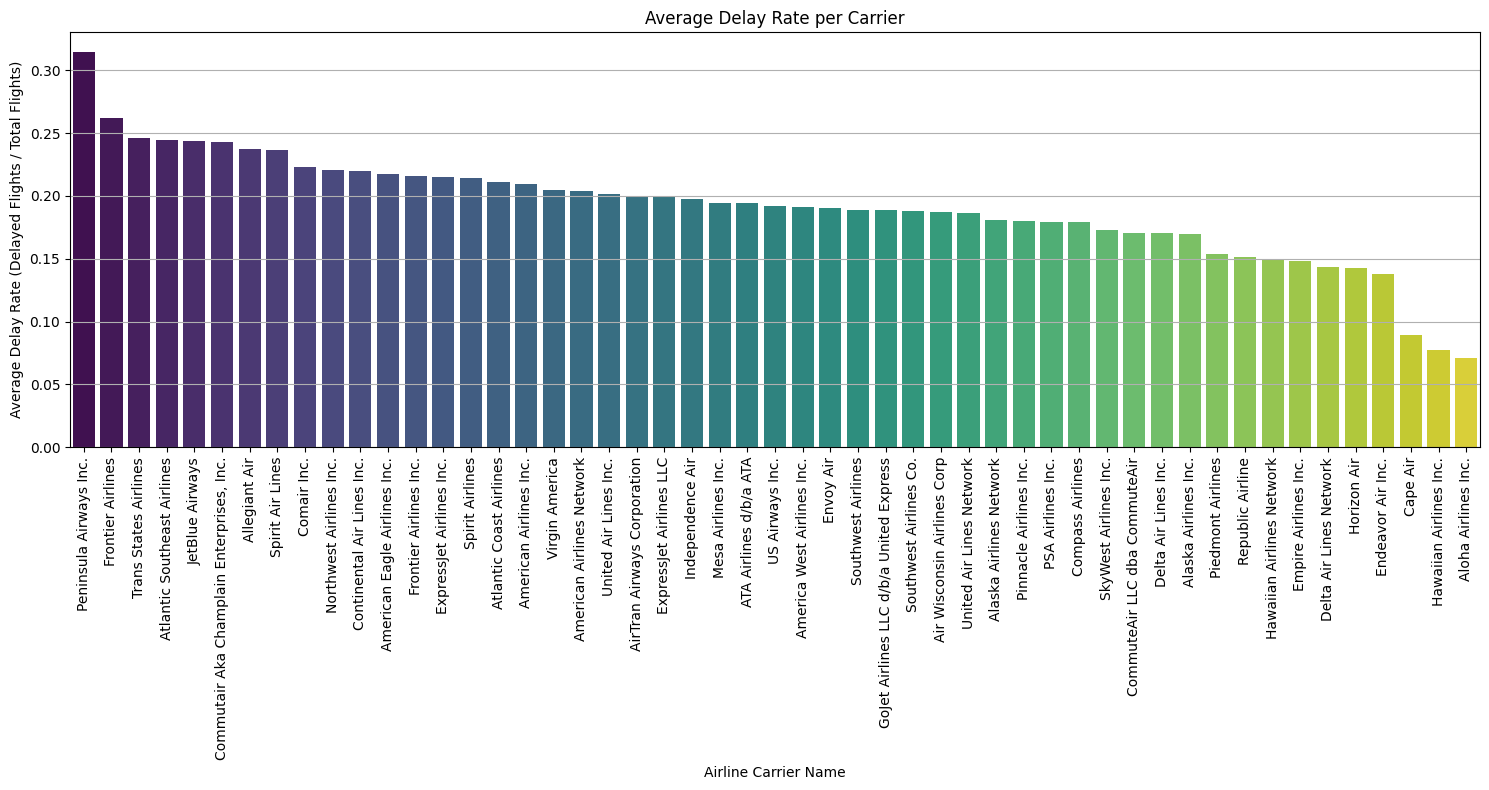

In [7]:
from pyspark.sql.functions import col, sum, avg

carrier_delay_rate = df.groupBy("carrier_name") \
                        .agg(sum("arr_del15").alias("total_delayed_flights"), \
                             sum("arr_flights").alias("total_flights"))

carrier_delay_rate = carrier_delay_rate.withColumn("delay_rate",
                                                   col("total_delayed_flights") / col("total_flights"))

carrier_delay_rate = carrier_delay_rate.fillna(0, subset=["delay_rate"]) \
                                       .orderBy(col("delay_rate").desc())

print("Top 10 airlines with the highest percentage of delayed flights:")
carrier_delay_rate.show(10, truncate=False)

carrier_delay_rate_pd = carrier_delay_rate.toPandas()

plt.figure(figsize=(15, 8))
sns.barplot(data=carrier_delay_rate_pd, x='carrier_name', y='delay_rate', palette='viridis')
plt.title('Average Delay Rate per Carrier')
plt.xlabel('Airline Carrier Name')
plt.ylabel('Average Delay Rate (Delayed Flights / Total Flights)')
plt.xticks(rotation=90)
plt.grid(axis='y')
plt.tight_layout()
plt.show()

Top 10 airlines with the most carrier-caused delays:
+-------------------------+---------------------------+
|carrier_name             |total_carrier_caused_delays|
+-------------------------+---------------------------+
|SkyWest Airlines Inc.    |873465.6399999987          |
|Southwest Airlines Co.   |862382.4499999996          |
|Southwest Airlines       |572138.8499999996          |
|American Airlines Inc.   |557837.3600000013          |
|Delta Air Lines Inc.     |486205.5400000016          |
|American Airlines Network|394088.7200000002          |
|United Air Lines Inc.    |383910.7000000003          |
|ExpressJet Airlines Inc. |370796.6800000004          |
|JetBlue Airways          |362771.3800000007          |
|Delta Air Lines Network  |338247.55999999994         |
+-------------------------+---------------------------+
only showing top 10 rows


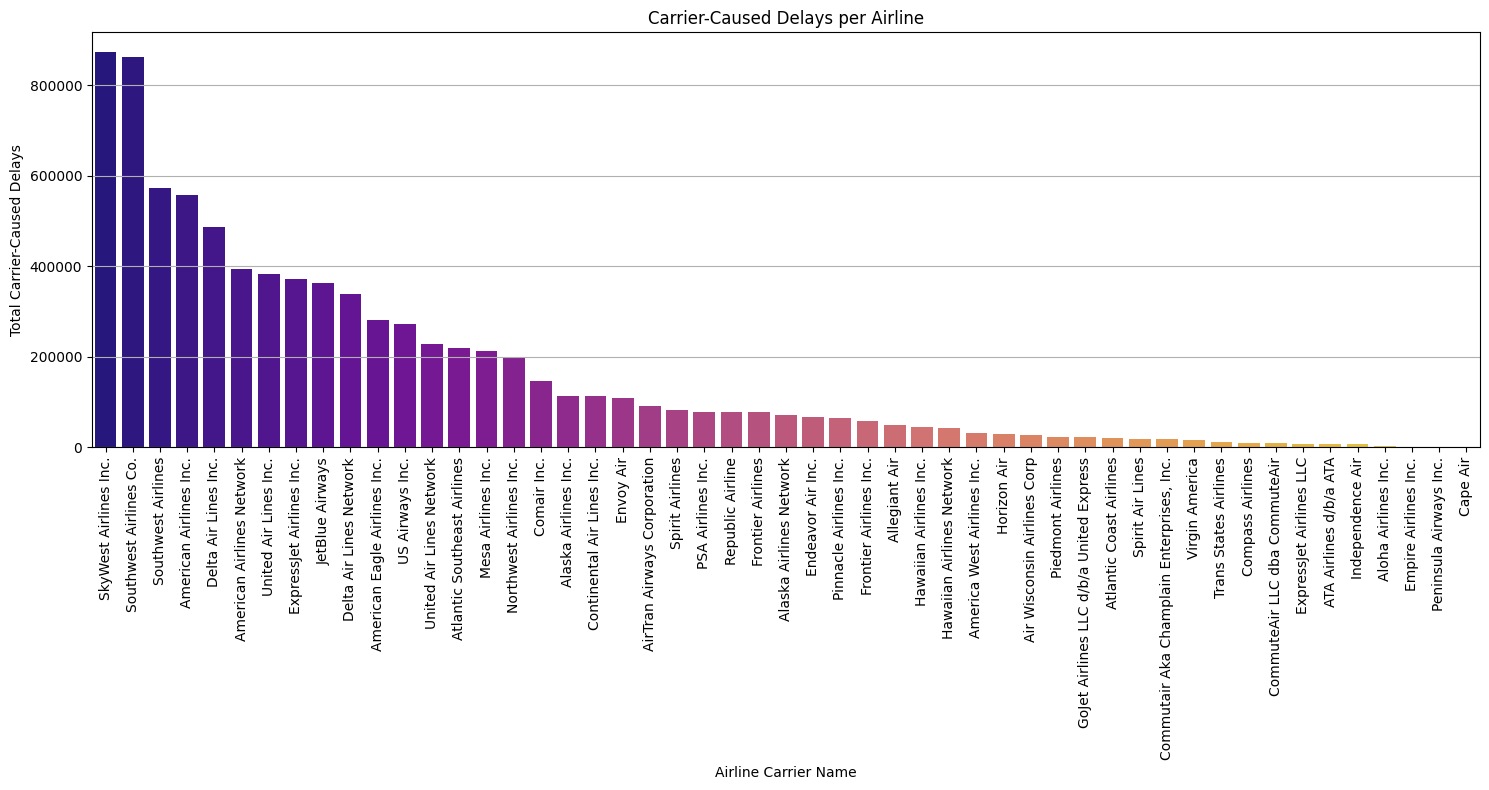

In [8]:
from pyspark.sql.functions import sum

carrier_caused_delays = df.groupBy("carrier_name") \
                            .agg(sum("carrier_ct").alias("total_carrier_caused_delays")) \
                            .orderBy(col("total_carrier_caused_delays").desc())

print("Top 10 airlines with the most carrier-caused delays:")
carrier_caused_delays.show(10, truncate=False)

carrier_caused_delays_pd = carrier_caused_delays.toPandas()

plt.figure(figsize=(15, 8))
sns.barplot(data=carrier_caused_delays_pd, x='carrier_name', y='total_carrier_caused_delays', palette='plasma', hue='carrier_name', legend=False)
plt.title('Carrier-Caused Delays per Airline')
plt.xlabel('Airline Carrier Name')
plt.ylabel('Total Carrier-Caused Delays')
plt.xticks(rotation=90)
plt.grid(axis='y')
plt.tight_layout()
plt.show()

Top 10 airports with the highest delay rates:
+-------------------------------------------------+---------------------+-------------+-------------------+
|airport_name                                     |total_delayed_flights|total_flights|delay_rate         |
+-------------------------------------------------+---------------------+-------------+-------------------+
|Youngstown/Warren, OH: Youngstown-Warren Regional|2                    |2            |1.0                |
|Pinehurst/Southern Pines, NC: Moore County       |133                  |317          |0.4195583596214511 |
|Unalaska, AK: Unalaska Airport                   |770                  |2074         |0.3712632594021215 |
|Topeka, KS: Topeka Regional                      |164                  |449          |0.36525612472160357|
|Cold Bay, AK: Cold Bay Airport                   |90                   |262          |0.3435114503816794 |
|Wilmington, DE: New Castle                       |688                  |2121         |0.3

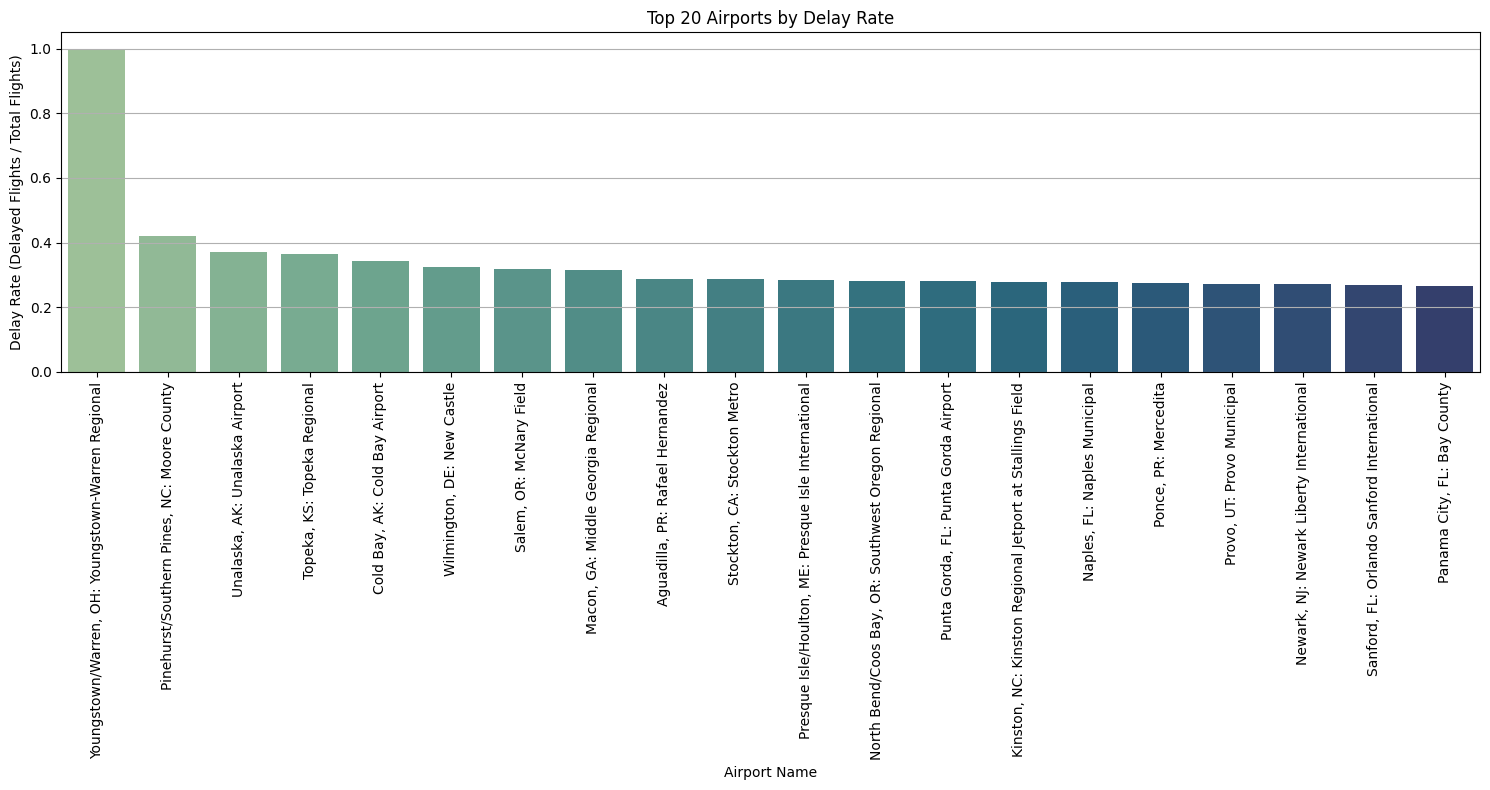

In [9]:
from pyspark.sql.functions import col, sum, when, lit

airport_delay_rate = df.groupBy("airport_name") \
                        .agg(sum("arr_del15").alias("total_delayed_flights"), \
                             sum("arr_flights").alias("total_flights"))

airport_delay_rate = airport_delay_rate.withColumn("delay_rate",
                                                   when(col("total_flights") == 0, lit(0)).otherwise(col("total_delayed_flights") / col("total_flights")))

airport_delay_rate = airport_delay_rate.fillna(0, subset=["delay_rate"]) \
                                       .orderBy(col("delay_rate").desc())

print("Top 10 airports with the highest delay rates:")
airport_delay_rate.show(10, truncate=False)

airport_delay_rate_pd = airport_delay_rate.toPandas()

plt.figure(figsize=(15, 8))
sns.barplot(data=airport_delay_rate_pd.head(20), x='airport_name', y='delay_rate', palette='crest', hue='airport_name', legend=False)
plt.title('Top 20 Airports by Delay Rate')
plt.xlabel('Airport Name')
plt.ylabel('Delay Rate (Delayed Flights / Total Flights)')
plt.xticks(rotation=90)
plt.grid(axis='y')
plt.tight_layout()
plt.show()

Delay cause distribution by year (percentages):
+----+------------------+------------------+------------------+------------------+-----------------+------------------+------------------+------------------+------------------+-------------------+--------------------+
|year|carrier_ct        |weather_ct        |nas_ct            |security_ct       |late_aircraft_ct |total_delays_count|carrier_ct_pct    |weather_ct_pct    |nas_ct_pct        |security_ct_pct    |late_aircraft_ct_pct|
+----+------------------+------------------+------------------+------------------+-----------------+------------------+------------------+------------------+------------------+-------------------+--------------------+
|2025|35994.74000000005 |5284.380000000004 |32859.130000000056|273.71999999999986|35192.91000000001|109604.88000000012|32.84045381920952 |4.821299927521474 |29.979623170063245|0.24973340603082597|32.108889677174936  |
|2024|485820.120000001  |57622.19000000005 |416812.37000000005|3981.780000000008

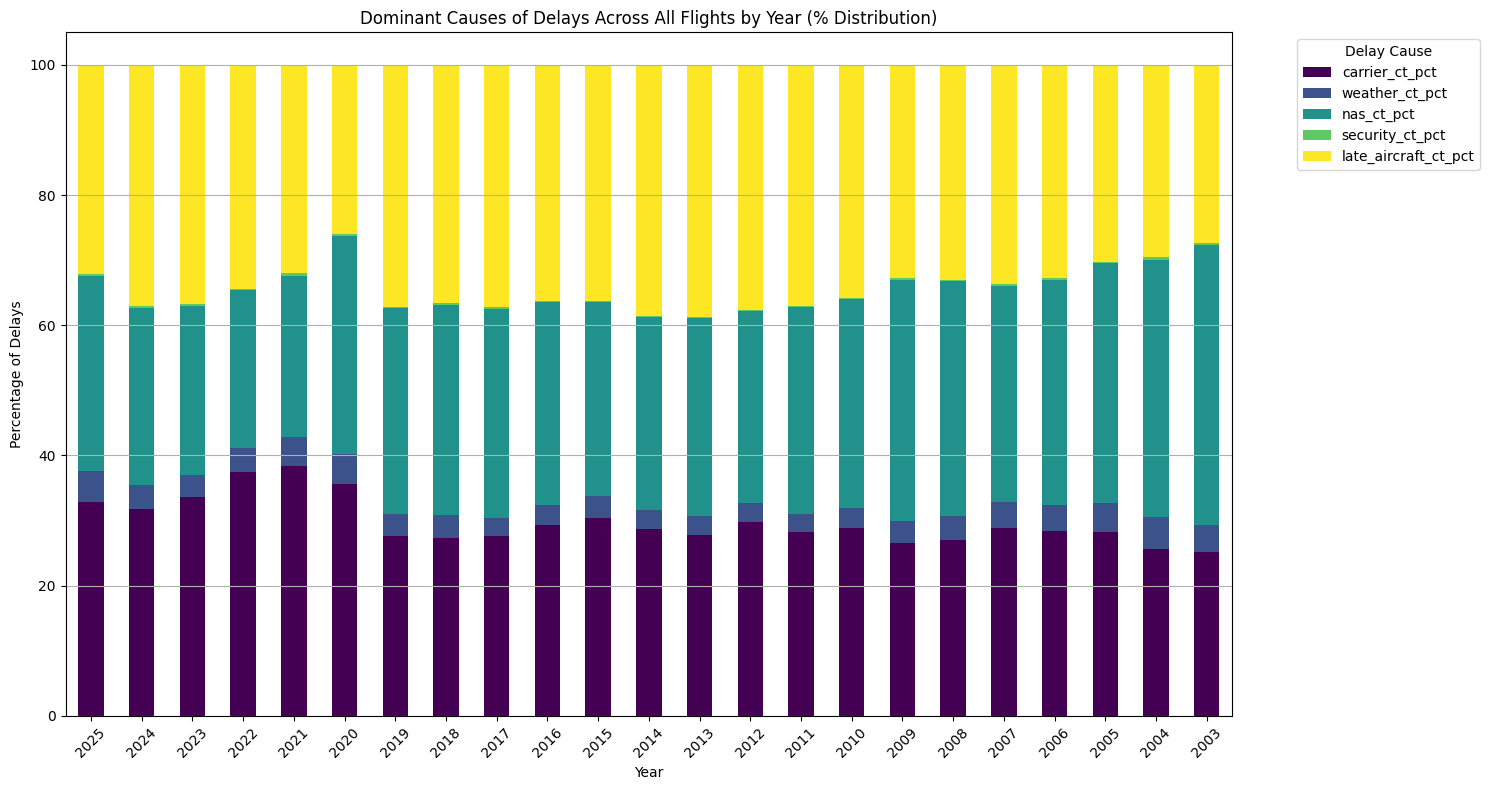

In [10]:
from pyspark.sql.functions import col, sum, year, desc
from functools import reduce
from operator import add

delay_cause_cols = ['carrier_ct', 'weather_ct', 'nas_ct', 'security_ct', 'late_aircraft_ct']

delay_causes_by_year = df.groupBy("year") \
                           .agg(*[sum(c).alias(c) for c in delay_cause_cols]) \
                           .orderBy(desc("year"))

delay_causes_by_year = delay_causes_by_year.withColumn("total_delays_count",
                                                       reduce(add, [col(c) for c in delay_cause_cols]))

for col_name in delay_cause_cols:
    delay_causes_by_year = delay_causes_by_year.withColumn(
        f"{col_name}_pct",
        (col(col_name) / col("total_delays_count")) * 100
    )

print("Delay cause distribution by year (percentages):")
delay_causes_by_year.show(5, truncate=False)

delay_causes_by_year_pd = delay_causes_by_year.toPandas()

plot_df = delay_causes_by_year_pd[['year'] + [f'{c}_pct' for c in delay_cause_cols]]

plot_df.set_index('year').plot(kind='bar', stacked=True, figsize=(15, 8), cmap='viridis')
plt.title('Dominant Causes of Delays Across All Flights by Year (% Distribution)')
plt.xlabel('Year')
plt.ylabel('Percentage of Delays')
plt.xticks(rotation=45)
plt.legend(title='Delay Cause', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(axis='y')
plt.tight_layout()
plt.show()

Delay cause distribution by month:
+-----+-----------------+------------------+-----------------+------------------+------------------+
|month|carrier_ct       |weather_ct        |nas_ct           |security_ct       |late_aircraft_ct  |
+-----+-----------------+------------------+-----------------+------------------+------------------+
|1    |695229.3900000013|101214.84000000013|775301.3099999991|5874.9            |776527.4600000014 |
|2    |587378.56        |80368.43999999994 |697369.4699999995|4636.6900000000005|686051.4100000008 |
|3    |668602.830000001 |65666.41999999998 |736361.5999999982|5840.680000000004 |795935.029999996  |
|4    |592979.5999999979|60836.24000000002 |657975.9999999999|4879.580000000004 |704912.0799999987 |
|5    |629577.3299999969|80206.46000000022 |712884.390000003 |4626.129999999997 |765547.8499999988 |
|6    |829000.2700000001|119398.0199999997 |857503.5099999984|6664.2100000000055|1032488.4200000023|
|7    |873918.7600000019|125390.75999999963|854304.59999

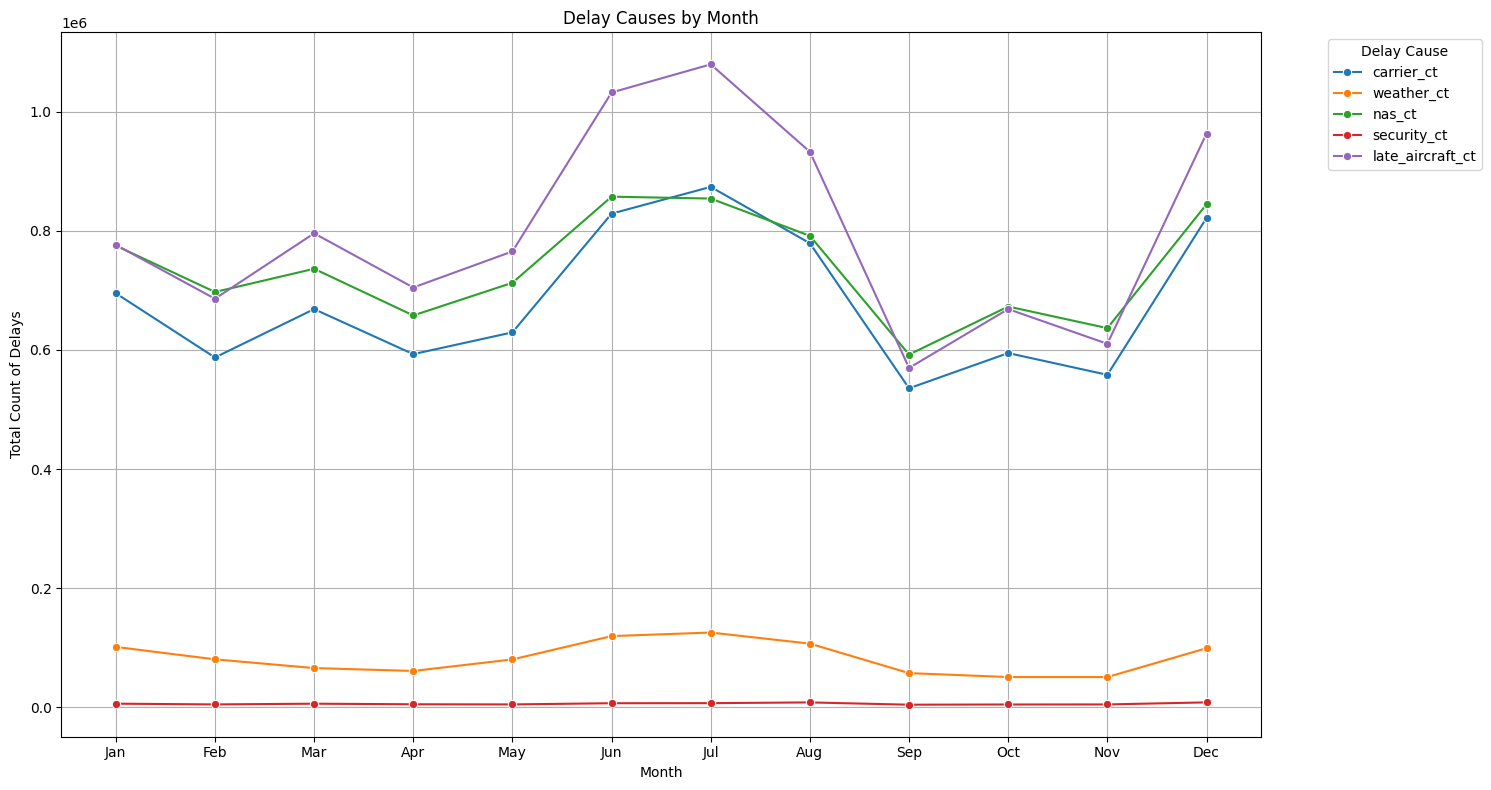

In [12]:
from pyspark.sql.functions import col, sum, month
import matplotlib.pyplot as plt
import seaborn as sns

delay_cause_cols = ['carrier_ct', 'weather_ct', 'nas_ct', 'security_ct', 'late_aircraft_ct']

delay_causes_by_month = df.groupBy("month") \
                            .agg(*[sum(c).alias(c) for c in delay_cause_cols]) \
                            .orderBy("month")

print("Delay cause distribution by month:")
delay_causes_by_month.show(12, truncate=False)

delay_causes_by_month_pd = delay_causes_by_month.toPandas()

plot_df_melted = delay_causes_by_month_pd.melt('month', var_name='Delay_Cause', value_name='Total_Count')

plt.figure(figsize=(15, 8))
sns.lineplot(data=plot_df_melted, x='month', y='Total_Count', hue='Delay_Cause', marker='o')
plt.title('Delay Causes by Month')
plt.xlabel('Month')
plt.ylabel('Total Count of Delays')
plt.xticks(range(1, 13), ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec'])
plt.grid(True)
plt.legend(title='Delay Cause', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

Monthly delay percentages:
+-----+---------------------+-------------+------------------+
|month|total_delayed_flights|total_flights|delay_percentage  |
+-----+---------------------+-------------+------------------+
|1    |2354148              |11988521     |19.63668412475567 |
|2    |2055802              |10553304     |19.48017417104634 |
|3    |2272405              |12121573     |18.746783111399814|
|4    |2021582              |11409296     |17.718726904797634|
|5    |2192840              |11636972     |18.843733576053978|
|6    |2845053              |12331062     |23.07224633206775 |
|7    |2940136              |12907171     |22.77908923651821 |
|8    |2618484              |12850510     |20.376498675928037|
|9    |1759080              |11804903     |14.901266024803423|
|10   |1991538              |12335061     |16.14534374819873 |
|11   |1860435              |11770852     |15.805440421814835|
|12   |2736989              |12079517     |22.65809965746147 |
+-----+---------------------

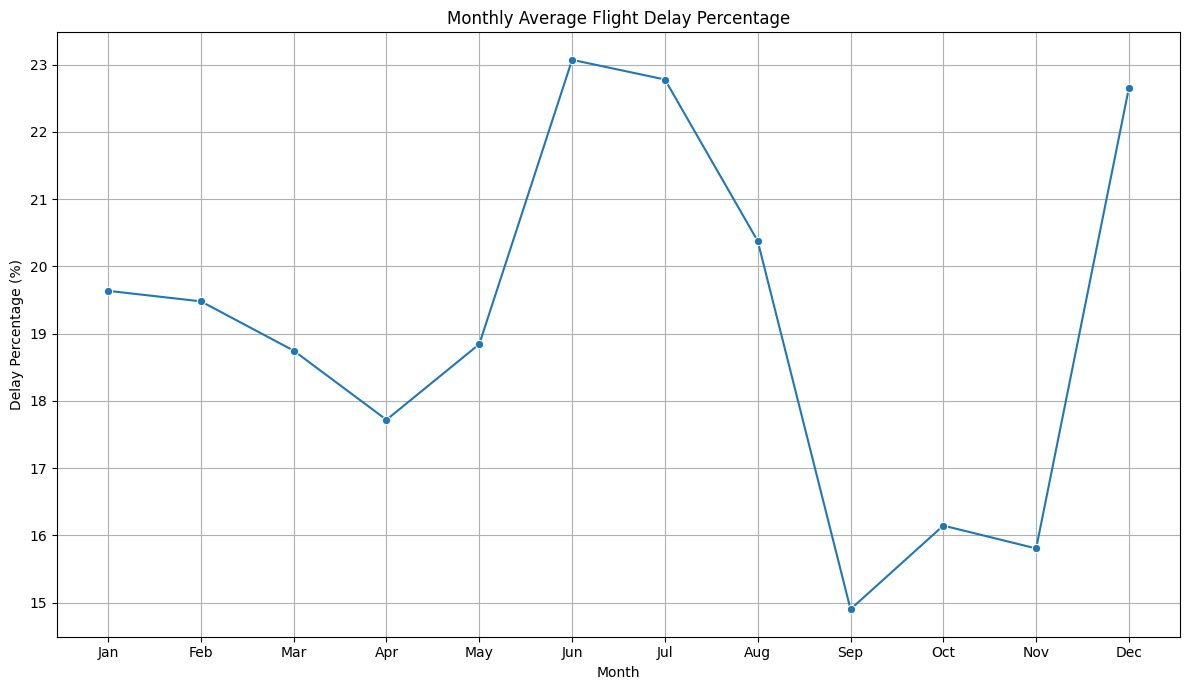

In [14]:
from pyspark.sql.functions import col, sum, avg
import matplotlib.pyplot as plt
import seaborn as sns

monthly_delay_stats = df.groupBy("month") \
                           .agg(sum("arr_del15").alias("total_delayed_flights"), \
                                sum("arr_flights").alias("total_flights")) \
                           .orderBy("month")

monthly_delay_stats = monthly_delay_stats.withColumn("delay_percentage",
                                                     (col("total_delayed_flights") / col("total_flights")) * 100)

print("Monthly delay percentages:")
monthly_delay_stats.show(12, truncate=False)

monthly_delay_stats_pd = monthly_delay_stats.toPandas()

plt.figure(figsize=(12, 7))
sns.lineplot(data=monthly_delay_stats_pd, x='month', y='delay_percentage', marker='o')
plt.title('Monthly Average Flight Delay Percentage')
plt.xlabel('Month')
plt.ylabel('Delay Percentage (%)')
plt.xticks(range(1, 13), ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec'])
plt.grid(True)
plt.tight_layout()
plt.show()